# PD Summary — One-shot QC + DSB Proximity Interpretation

This notebook is designed to be **run top-to-bottom** and then shared (export to HTML/PDF if desired).

It will:
1) explain the expected input format
2) load all `*_summary.csv` / `*_collapsed_summary.csv` in the PD folder
3) run QC and CIS/TRANS summaries in a framework focused on **DSB monitoring and allele-association proximity**
4) (optionally) save plots and key summary tables to a local `Outputs/` folder

## Biological context (Aim 3)

This PD dataset is interpreted in the same conceptual framework as your 3C analyses:
- Two simultaneous DSBs can repair in **cis** (cognate ends) or **trans** (non-cognate ends).
- Prior results showed cis predominance, but a surprisingly stable trans frequency across many locus pairs.
- That pattern supports a working model in which **post-damage DSB movement/co-localization** can reduce the influence of pre-damage distance.

So in this report, the key readout is not just "damage happened", but **which allele/locus partners are being observed together over time**.

## Data location
This notebook reads from `WILSONTEW_PD_FOLDER` if set; otherwise it falls back to `./PD_Data`.
Current recommended PD folder (from your setup):
- `C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data`

In [2]:
suppressPackageStartupMessages({
  library(tidyverse)
})


## Expected columns (typical)
Most PD summary CSVs include columns like:
- `batch`, `time_point`, `DSB`, `allele`, `combo`, `cis_trans`, `count`
Optional but supported:
- `repeat` (e.g., INTACT/SSA)
- `replicate`
- `alignment_name`

If any optional columns are missing, we will add reasonable defaults.

### Interpretation note
In this workflow, the important signal is **DSB partner usage by allele/locus over time**. 
That means "trans" should be read as **non-cognate partnering behavior** in this assay context, and then integrated with your broader DSB movement/proximity hypothesis.

In [3]:
# ---- Locate PD folder ----
pd_folder <- Sys.getenv('WILSONTEW_PD_FOLDER', unset = file.path(getwd(), 'PD_Data'))
pd_folder <- normalizePath(pd_folder, winslash = '/', mustWork = FALSE)
dir.create(pd_folder, recursive = TRUE, showWarnings = FALSE)
message('Using pd_folder: ', pd_folder)

files <- list.files(pd_folder, pattern = '(_summary|_collapsed_summary)\\.csv$', full.names = TRUE)
if (length(files) == 0) {
  stop(paste0(
    'No *_summary.csv or *_collapsed_summary.csv files found in pd_folder: ', pd_folder,
    '\n\nFix: copy the PD summary CSVs into that folder, or set WILSONTEW_PD_FOLDER to the directory that contains them.'
  ))
}
message('Found ', length(files), ' file(s).')
head(files, 10)

Using pd_folder: C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data

Found 4 file(s).



[1] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch6_T0_PD_UMI_plus_singletons_collapsed_summary.csv"  
[2] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch6_T180_PD_UMI_plus_singletons_collapsed_summary.csv"
[3] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch8_T0_PD_UMI_plus_singletons_collapsed_summary.csv"  
[4] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch8_T180_PD_UMI_plus_singletons_collapsed_summary.csv"

In [4]:
# ---- Read and combine ----
read_one <- function(f) {
  dat <- readr::read_csv(f, show_col_types = FALSE)
  if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
  if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
  if (!("alignment_name" %in% names(dat))) dat <- dplyr::mutate(dat, alignment_name = NA_character_)
  dat <- dplyr::mutate(
    dat,
    source_path = f,
    source_dir = dirname(f),
    allele = as.character(.data[["allele"]]),
    combo = as.character(.data[["combo"]]),
    cis_trans = as.character(.data[["cis_trans"]]),
    DSB = as.character(.data[["DSB"]]),
    `repeat` = as.character(.data[["repeat"]]),
    replicate = as.character(.data[["replicate"]]),
    batch = as.character(.data[["batch"]])
  )
  dat
}

dat_raw <- purrr::map_dfr(files, read_one)
dat_raw <- dplyr::mutate(dat_raw, batch = factor(batch, levels = sort(unique(batch))))
dplyr::glimpse(dat_raw)

Rows: 659
Columns: 13
$ batch          <fct> 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6…
$ DSB2_loci      <chr> "chr4", "chr4", "chr4", "chr4", "chr4", "chr4", "chr4",…
$ time_point     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ replicate      <chr> "1", "1", "1", "1", "1", "1", "1", "1", "1", "1", "1", …
$ alignment_name <chr> "CIS_DSB1_FULL_CHRIII_L02", "CIS_DSB1_FULL_CHRIII_L03",…
$ cis_trans      <chr> "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS",…
$ DSB            <chr> "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1",…
$ combo          <chr> "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to…
$ `repeat`       <chr> "INTACT", "INTACT", "INTACT", "INTACT", "INTACT", "INTA…
$ allele         <chr> "CHRIII_L02", "CHRIII_L03", "CHRIII_L04", "CHRIV_L01", …
$ count          <dbl> 51283, 38174, 228463, 49541, 32857, 54088, 39551, 44777…
$ source_path    <chr> "C:/Users/dunnmk/University of Michigan Dropbox/MED-WIL…
$ source_dir     <

In [9]:
# ---- Quick sanity tables ----
dat_raw %>%
  count(batch, time_point, DSB, sort = TRUE, name = 'n_rows') %>%
  head(30)


batch,time_point,DSB,n_rows
<fct>,<dbl>,<chr>,<int>
6,180,TRANS,80
8,180,TRANS,79
6,0,TRANS,57
6,0,DSB1,52
6,180,DSB1,52
6,180,DSB2,52
8,0,DSB1,52
8,180,DSB1,52
8,180,DSB2,52


## QC plots tied to the DSB movement model
These plots answer two biological questions before deeper analysis:

1. **Was DSB induction/measurement balanced enough across groups to trust comparisons?**  
   - Checked by total counts across batch/time/DSB.
2. **Do cis/trans proportions change in ways consistent with locus-specific bias or with broader coordinated movement?**  
   - Checked by CIS vs TRANS percent trajectories across time and DSB groups.

If trans proportions are similar across many locus contexts (despite different expected pre-damage proximity), that supports the Aim 3 model of post-damage movement/co-localization.

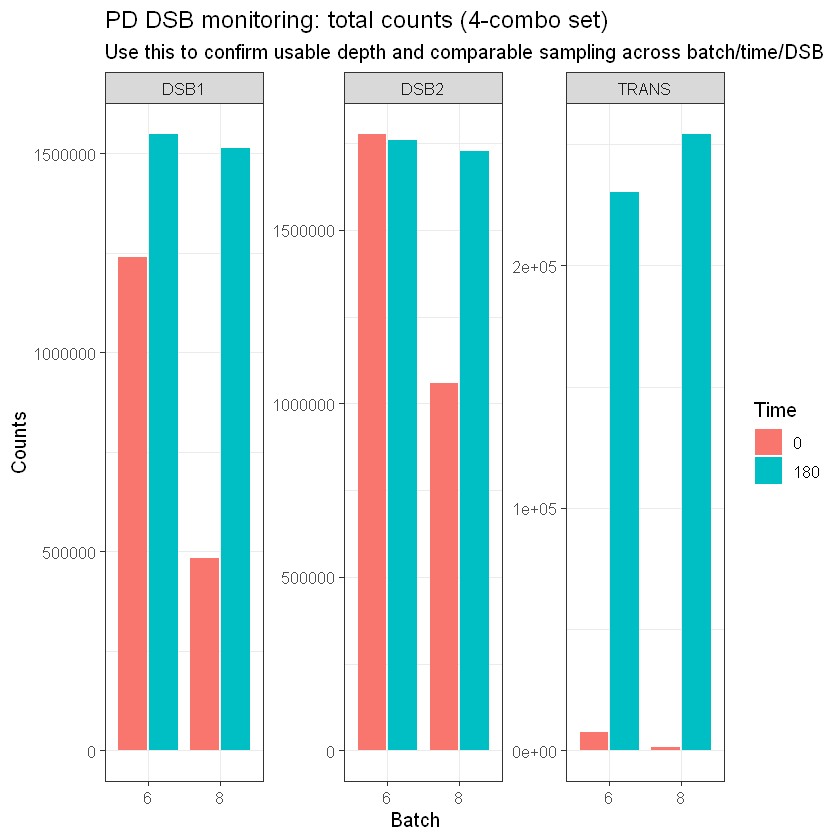

batch,time_point,DSB,class,Counts,Percent
<fct>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
6,0,DSB1,CIS,1238149,100
6,180,DSB1,CIS,1549523,100
8,0,DSB1,CIS,483724,100
8,180,DSB1,CIS,1511971,100
6,0,DSB2,CIS,1777638,100
6,180,DSB2,CIS,1759385,100
8,0,DSB2,CIS,1057475,100
8,180,DSB2,CIS,1726168,100
6,0,TRANS,TRANS,7447,100


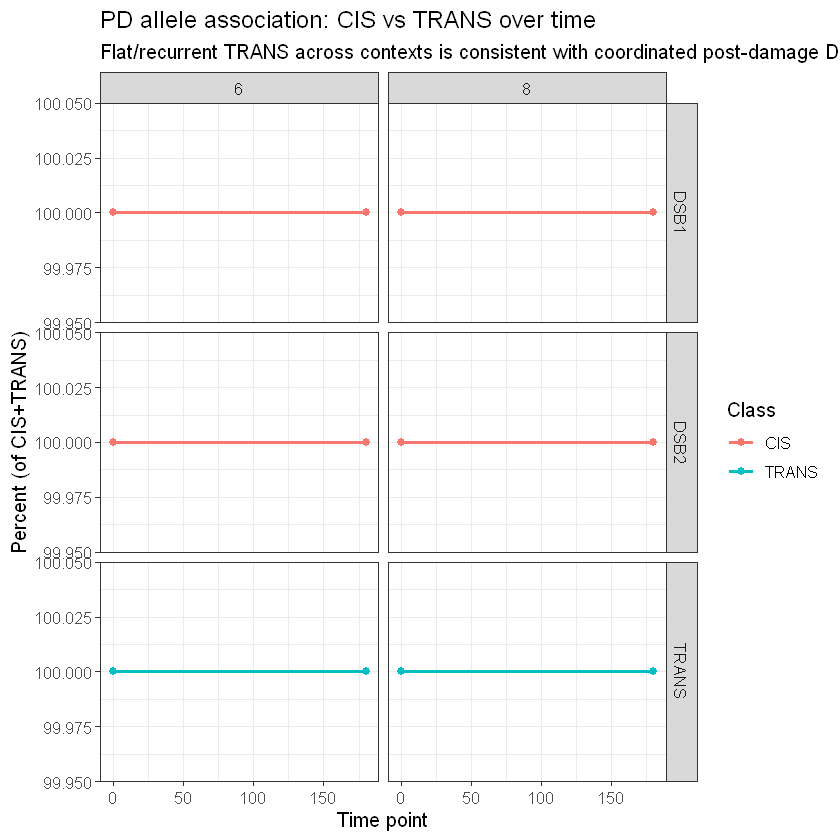

In [5]:
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

dat4 <- dat_raw %>% filter(combo %in% combos_4)

# Total counts per group (DSB monitoring/QC: depth and balance)
qc_totals <- dat4 %>%
  group_by(batch, time_point, DSB) %>%
  summarise(Total_Counts = sum(count, na.rm = TRUE), .groups = 'drop')

p_total <- ggplot(qc_totals, aes(x = batch, y = Total_Counts, fill = factor(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  facet_wrap(~ DSB, scales = 'free_y') +
  theme_bw(base_size = 12) +
  labs(
    title = 'PD DSB monitoring: total counts (4-combo set)',
    subtitle = 'Use this to confirm usable depth and comparable sampling across batch/time/DSB',
    x = 'Batch', y = 'Counts', fill = 'Time'
  )
print(p_total)

# CIS/TRANS percent over time (allele partner-choice readout)
qc_cistrans <- dat4 %>%
  mutate(class = case_when(combo %in% cis_combos ~ 'CIS', combo %in% trans_combos ~ 'TRANS', TRUE ~ 'OTHER')) %>%
  group_by(batch, time_point, DSB, class) %>%
  summarise(Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(batch, time_point, DSB) %>%
  mutate(Percent = if_else(sum(Counts, na.rm = TRUE) > 0, 100 * Counts / sum(Counts, na.rm = TRUE), NA_real_)) %>%
  ungroup()

p_cistrans <- ggplot(
  qc_cistrans %>% filter(class %in% c('CIS', 'TRANS')),
  aes(x = as.numeric(as.character(time_point)), y = Percent, color = class)
 ) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2) +
  facet_grid(DSB ~ batch) +
  theme_bw(base_size = 12) +
  labs(
    title = 'PD allele association: CIS vs TRANS over time',
    subtitle = 'Flat/recurrent TRANS across contexts is consistent with coordinated post-damage DSB movement',
    x = 'Time point', y = 'Percent (of CIS+TRANS)', color = 'Class'
  )
print(p_cistrans)

# Compact table for quick reporting
qc_cistrans %>%
  filter(class %in% c('CIS', 'TRANS')) %>%
  arrange(DSB, batch, time_point, class) %>%
  head(30)

## How to read these PD outputs biologically

- **Total-count plot (`p_total`)**: confirms signal depth and comparability; large imbalances can mimic biology.
- **CIS/TRANS trajectory plot (`p_cistrans`)**: your primary PD readout for partner choice dynamics.
- If cis stays dominant but trans remains present at similar levels across many DSB contexts, that matches your Aim 2/3 observation that pre-damage proximity alone does not explain trans behavior.
- This is exactly the bridge to the 3C/HTGTS logic: test whether changing **post-damage co-localization** explains the observed partner distributions.

## Integrated PD + 3C contact maps (state-aligned endpoints)

This section integrates **pull-down (PD)** and **3C** data without requiring identical assay endpoints.

### Key update
- Integration is done by **shared biological state** rather than exact `time_point` values.
- State labels used here are **Uncut DSB** and **Cut DSB**.

### How state alignment works
- Each assay maps its time points into states using editable dictionaries in the code cell below.
- Defaults are provided (e.g., PD `0 -> Uncut DSB`, `180 -> Cut DSB`; 3C `0 -> Uncut DSB`, `120/180 -> Cut DSB`).
- Any unmapped times fall back to: earliest = `Uncut DSB`, others = `Cut DSB`.

### What is plotted
1. **Integrated contact map** (fusion score), faceted by DSB and state.
2. **Comparison panels** for PD-only, 3C-only, and Integrated maps (same clustered allele order).
3. **PD vs 3C concordance scatter** for cross-assay agreement.
4. **Differential contact map** (`Cut DSB - Uncut DSB`).
5. **Rank-shift slopegraph** of integrated allele prominence.
6. **PD-vs-3C residual map** showing contacts beyond PD-predicted 3C behavior.

3C folder: C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary

3C files found: 8



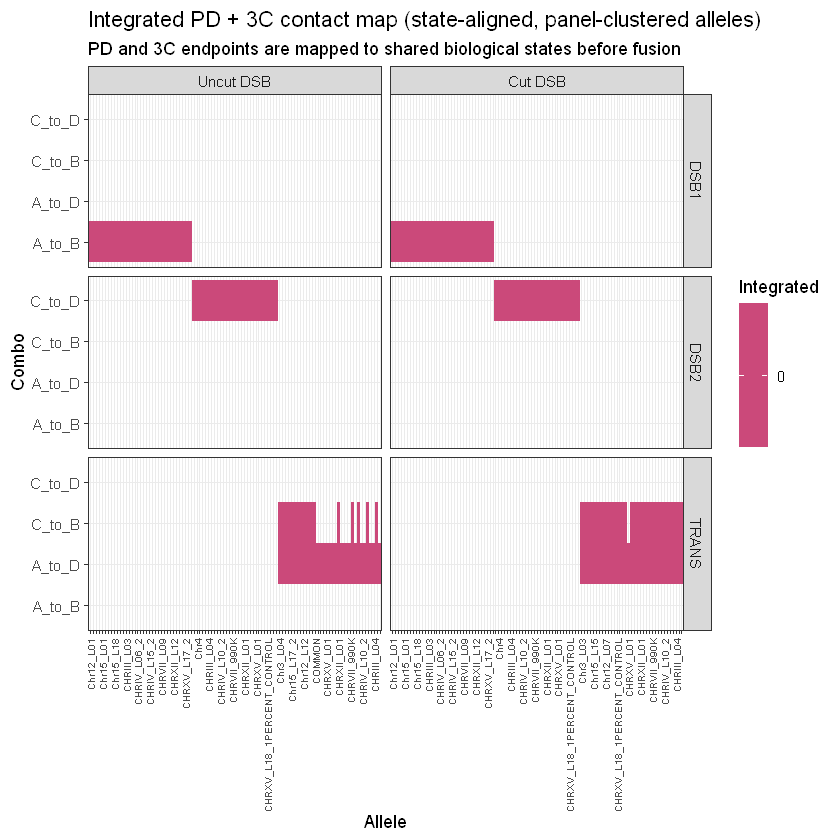

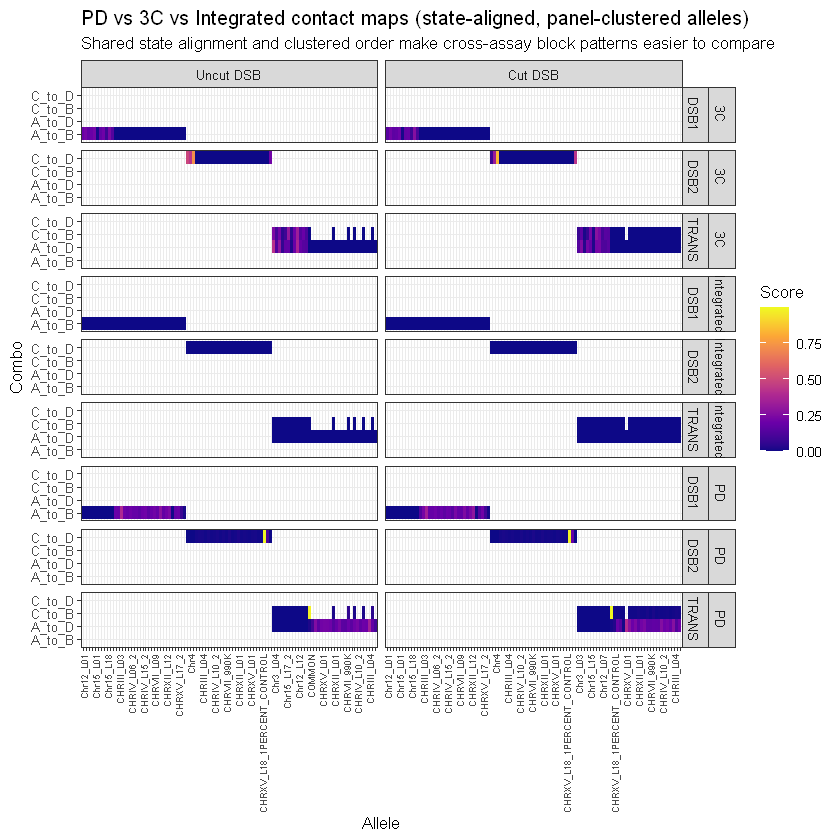

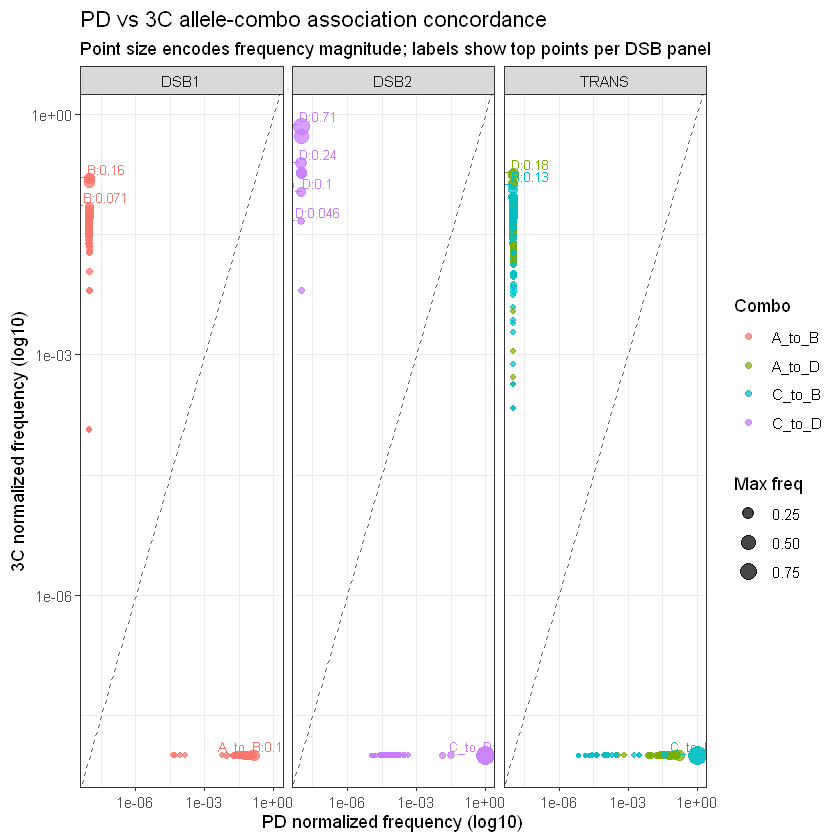

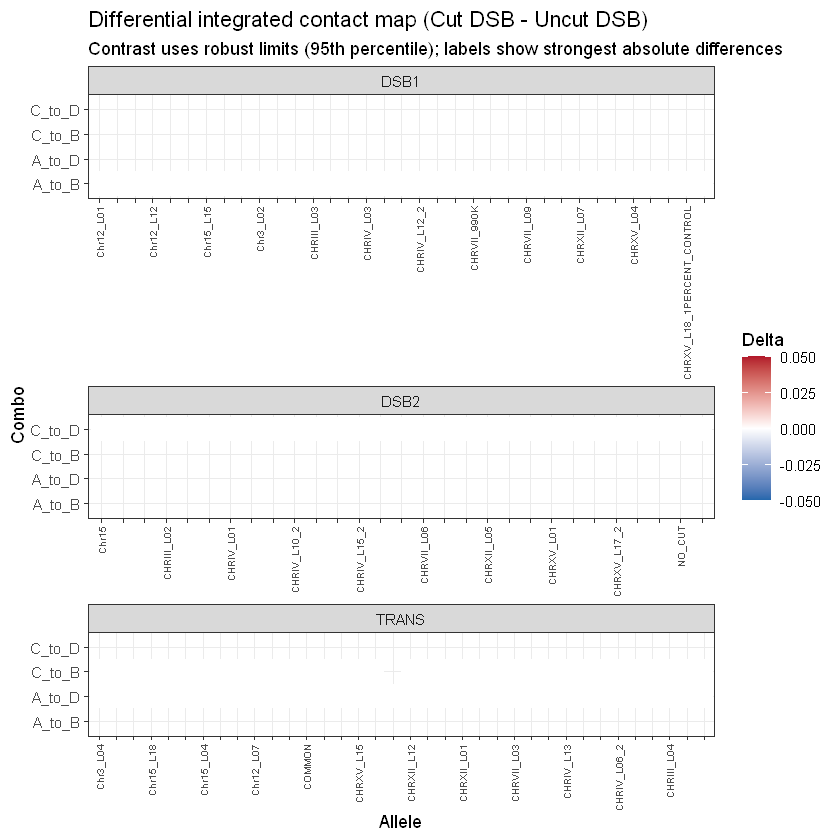

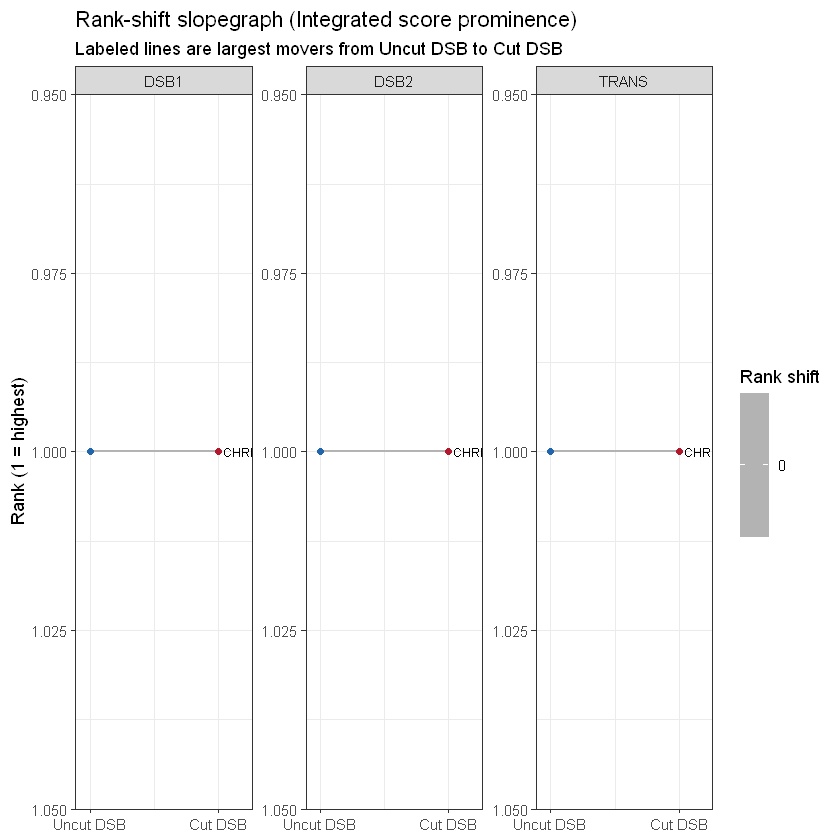

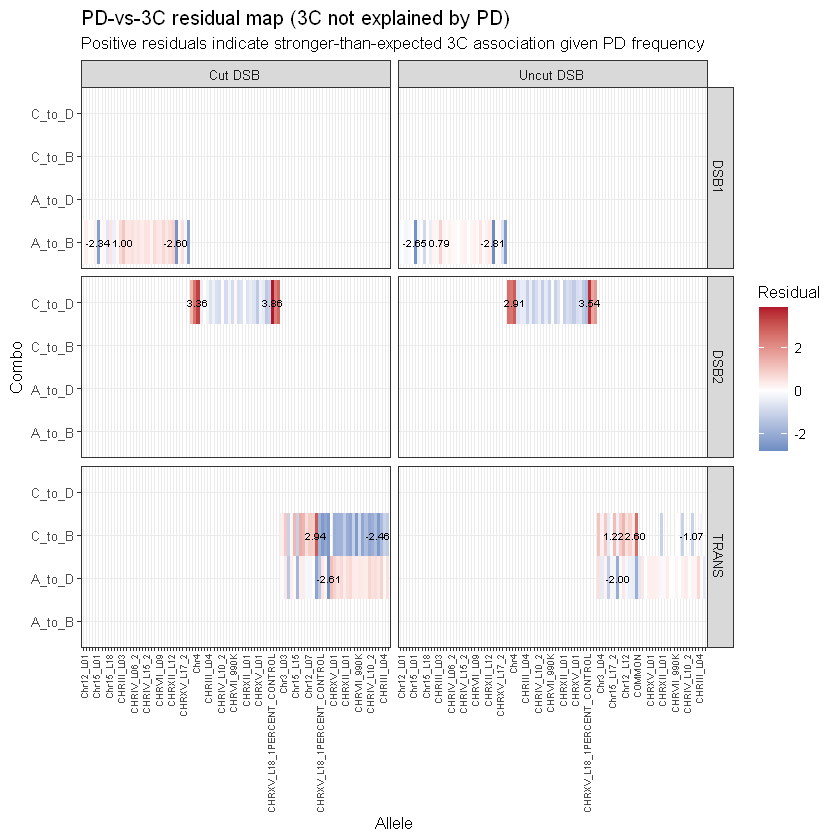

In [19]:
# ---- Integrated PD + 3C contact-map analysis (state-aligned endpoints) ----
if (!exists('dat4') || nrow(dat4) == 0) {
  stop('dat4 is empty. Run previous cells first.')
}

# Locate 3C source folder
threec_folder <- Sys.getenv('WILSONTEW_3C_FOLDER', unset = file.path(getwd(), 'ThreeC_Data'))
threec_folder <- normalizePath(threec_folder, winslash = '/', mustWork = FALSE)

threec_files <- c(
  list.files(threec_folder, pattern = '_summary\\.csv$', full.names = TRUE),
  list.files(threec_folder, pattern = '_collapsed_summary\\.csv$', full.names = TRUE)
) %>% unique()

message('3C folder: ', threec_folder)
message('3C files found: ', length(threec_files))

state_uncut <- 'Uncut DSB'
state_cut <- 'Cut DSB'

# -------- State mapping helpers --------
assign_state <- function(tp, map_vec, uncut_label = state_uncut, cut_label = state_cut) {
  tp_chr <- as.character(tp)
  mapped <- unname(map_vec[tp_chr])
  # fallback: earliest observed endpoint is uncut, others are cut
  tp_num <- suppressWarnings(as.numeric(tp_chr))
  min_tp <- suppressWarnings(min(tp_num, na.rm = TRUE))
  fallback <- ifelse(!is.na(tp_num) & tp_num == min_tp, uncut_label, cut_label)
  ifelse(is.na(mapped), fallback, mapped)
}

# axis label helper: keep every n-th label to reduce crowding
sparse_axis_labels <- function(x, step = 4) {
  labs <- sub('^.*__', '', x)
  idx <- seq_along(labs)
  labs[!(idx %% step == 1)] <- ''
  labs
}

# Editable endpoint->state dictionaries
# (Keys are time_point values as strings)
pd_state_map <- c(
  '0' = state_uncut,
  '180' = state_cut
)
threec_state_map <- c(
  '0' = state_uncut,
  '120' = state_cut,
  '180' = state_cut
)

# Default placeholders if 3C is unavailable
threec_sig <- tibble::tibble()
fusion_df <- tibble::tibble()
p_contact_map_integrated <- NULL
p_contact_map_compare <- NULL
p_pd3c_assoc <- NULL
p_diff_contact_map <- NULL
p_rank_shift <- NULL
p_pd3c_residual_map <- NULL

# Build state-aligned PD signal
pd_sig <- dat4 %>%
  mutate(state = assign_state(time_point, pd_state_map)) %>%
  group_by(DSB, state, combo, allele) %>%
  summarise(PD_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, state, combo) %>%
  mutate(
    PD_Total = sum(PD_Counts, na.rm = TRUE),
    PD_Freq = ifelse(PD_Total > 0, PD_Counts / PD_Total, NA_real_)
  ) %>%
  ungroup()

if (length(threec_files) == 0) {
  warning('No 3C files found. Set WILSONTEW_3C_FOLDER (or place files in ./ThreeC_Data) to enable integrated maps.')
} else {
  # Read 3C robustly
  read_threec <- function(f) {
    x <- readr::read_csv(
      f,
      show_col_types = FALSE,
      col_types = readr::cols(.default = readr::col_character())
    )

    required <- c('DSB', 'time_point', 'combo', 'allele', 'count')
    missing <- setdiff(required, names(x))
    if (length(missing) > 0) return(NULL)

    x %>%
      mutate(
        DSB = as.character(.data[['DSB']]),
        combo = as.character(.data[['combo']]),
        allele = as.character(.data[['allele']]),
        time_point = readr::parse_number(as.character(.data[['time_point']])),
        count = readr::parse_double(as.character(.data[['count']]))
      ) %>%
      select(DSB, time_point, combo, allele, count)
  }

  threec_raw <- purrr::map(threec_files, read_threec) %>%
    purrr::compact() %>%
    dplyr::bind_rows()

  if (nrow(threec_raw) == 0) {
    warning('3C files were found, but required columns were missing. Skipping integration.')
  } else {
    threec_sig <- threec_raw %>%
      mutate(state = assign_state(time_point, threec_state_map)) %>%
      filter(combo %in% unique(pd_sig$combo)) %>%
      group_by(DSB, state, combo, allele) %>%
      summarise(ThreeC_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
      group_by(DSB, state, combo) %>%
      mutate(
        ThreeC_Total = sum(ThreeC_Counts, na.rm = TRUE),
        ThreeC_Freq = ifelse(ThreeC_Total > 0, ThreeC_Counts / ThreeC_Total, NA_real_)
      ) %>%
      ungroup()

    # Align to shared keyspace (by DSB + state + combo + allele)
    fusion_df <- full_join(
      pd_sig %>% select(DSB, state, combo, allele, PD_Freq),
      threec_sig %>% select(DSB, state, combo, allele, ThreeC_Freq),
      by = c('DSB', 'state', 'combo', 'allele')
    ) %>%
      mutate(
        PD_Freq = replace_na(PD_Freq, 0),
        ThreeC_Freq = replace_na(ThreeC_Freq, 0),
        Integrated_Raw = ifelse(PD_Freq + ThreeC_Freq > 0,
                                2 * PD_Freq * ThreeC_Freq / (PD_Freq + ThreeC_Freq),
                                0)
      ) %>%
      group_by(DSB, state) %>%
      mutate(
        Integrated_Score = ifelse(max(Integrated_Raw, na.rm = TRUE) > 0,
                                 Integrated_Raw / max(Integrated_Raw, na.rm = TRUE),
                                 0)
      ) %>%
      ungroup()

    # Keep most informative alleles per panel
    top_n <- 35
    top_alleles_panel <- fusion_df %>%
      group_by(DSB, state, allele) %>%
      summarise(Total_Integrated = sum(Integrated_Score, na.rm = TRUE), .groups = 'drop') %>%
      group_by(DSB, state) %>%
      slice_max(order_by = Total_Integrated, n = top_n, with_ties = FALSE) %>%
      ungroup()

    fusion_plot <- fusion_df %>%
      inner_join(top_alleles_panel %>% select(DSB, state, allele), by = c('DSB', 'state', 'allele'))

    # Cluster allele order separately for each DSB/state panel
    panel_orders <- fusion_plot %>%
      group_by(DSB, state) %>%
      group_modify(~ {
        wide <- .x %>%
          select(allele, combo, Integrated_Score) %>%
          distinct() %>%
          pivot_wider(names_from = combo, values_from = Integrated_Score, values_fill = 0)

        allele_names <- wide$allele
        mat <- wide %>% select(-allele) %>% as.matrix()

        if (length(allele_names) >= 3 && ncol(mat) >= 2) {
          hc <- hclust(dist(mat), method = 'ward.D2')
          ordered <- allele_names[hc$order]
        } else {
          ordered <- sort(allele_names)
        }

        tibble(
          allele = ordered,
          allele_ord = seq_along(ordered)
        )
      }) %>%
      ungroup()

    fusion_plot <- fusion_plot %>%
      left_join(panel_orders, by = c('DSB', 'state', 'allele')) %>%
      mutate(
        state = factor(state, levels = c(state_uncut, state_cut)),
        panel_key = paste0(DSB, '__', as.character(state)),
        allele_panel = paste0(panel_key, '__', sprintf('%03d', allele_ord), '__', allele)
      )

    allele_panel_levels <- fusion_plot %>%
      distinct(DSB, state, allele_ord, allele_panel) %>%
      arrange(DSB, state, allele_ord) %>%
      pull(allele_panel)

    fusion_plot <- fusion_plot %>%
      mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

    # Integrated map (panel-clustered order)
    p_contact_map_integrated <- ggplot(fusion_plot, aes(x = allele_panel, y = combo, fill = sqrt(Integrated_Score))) +
      geom_tile() +
      facet_grid(DSB ~ state, scales = 'free_x', space = 'free_x') +
      scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
      scale_fill_viridis_c(option = 'C', na.value = 'grey90') +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6)) +
      labs(
        title = 'Integrated PD + 3C contact map (state-aligned, panel-clustered alleles)',
        subtitle = 'PD and 3C endpoints are mapped to shared biological states before fusion',
        x = 'Allele', y = 'Combo', fill = 'Integrated'
      )
    print(p_contact_map_integrated)

    # Side-by-side comparison maps with same clustered order
    compare_long <- bind_rows(
      fusion_plot %>% transmute(DSB, state, combo, allele_panel, Source = 'PD', Score = PD_Freq),
      fusion_plot %>% transmute(DSB, state, combo, allele_panel, Source = '3C', Score = ThreeC_Freq),
      fusion_plot %>% transmute(DSB, state, combo, allele_panel, Source = 'Integrated', Score = Integrated_Score)
)

    p_contact_map_compare <- ggplot(compare_long, aes(x = allele_panel, y = combo, fill = sqrt(Score))) +
      geom_tile() +
      facet_grid(Source + DSB ~ state, scales = 'free_x', space = 'free_x') +
      scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
      scale_fill_viridis_c(option = 'C', na.value = 'grey90') +
      theme_bw(base_size = 10) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5.5)) +
      labs(
        title = 'PD vs 3C vs Integrated contact maps (state-aligned, panel-clustered alleles)',
        subtitle = 'Shared state alignment and clustered order make cross-assay block patterns easier to compare',
        x = 'Allele', y = 'Combo', fill = 'Score'
      )
    print(p_contact_map_compare)

    # Concordance scatter with size labels for strongest points
    concord_df <- fusion_df %>%
      filter(PD_Freq > 0 | ThreeC_Freq > 0) %>%
      mutate(PointSize = pmax(PD_Freq, ThreeC_Freq))

    label_points <- concord_df %>%
      group_by(DSB) %>%
      slice_max(order_by = PointSize, n = 10, with_ties = FALSE) %>%
      ungroup() %>%
      mutate(Label = paste0(combo, ':', signif(PointSize, 2)))

    p_pd3c_assoc <- ggplot(concord_df, aes(x = PD_Freq + 1e-8, y = ThreeC_Freq + 1e-8, color = combo, size = PointSize)) +
      geom_point(alpha = 0.72) +
      geom_abline(slope = 1, intercept = 0, linetype = 'dashed', color = 'grey40') +
      geom_text(
        data = label_points,
        aes(label = Label),
        size = 2.7,
        check_overlap = TRUE,
        show.legend = FALSE,
        vjust = -0.4
      ) +
      scale_x_log10() +
      scale_y_log10() +
      scale_size_continuous(range = c(1.2, 5), name = 'Max freq') +
      facet_wrap(~ DSB) +
      theme_bw(base_size = 11) +
      labs(
        title = 'PD vs 3C allele-combo association concordance',
        subtitle = 'Point size encodes frequency magnitude; labels show top points per DSB panel',
        x = 'PD normalized frequency (log10)',
        y = '3C normalized frequency (log10)',
        color = 'Combo'
      )
    print(p_pd3c_assoc)

    # ---- New plot 1: Differential contact map (Cut - Uncut) ----
    if (all(c(state_uncut, state_cut) %in% unique(fusion_df$state))) {
      diff_df <- fusion_df %>%
        select(DSB, state, combo, allele, Integrated_Score) %>%
        pivot_wider(names_from = state, values_from = Integrated_Score, values_fill = 0) %>%
        mutate(Delta_Cut_minus_Uncut = .data[[state_cut]] - .data[[state_uncut]])

      order_ref <- fusion_plot %>%
        mutate(state_priority = if_else(as.character(state) == state_cut, 1L, 2L)) %>%
        arrange(DSB, allele, state_priority) %>%
        group_by(DSB, allele) %>%
        slice(1) %>%
        ungroup() %>%
        select(DSB, allele, allele_panel)

      diff_plot <- diff_df %>%
        inner_join(order_ref, by = c('DSB', 'allele')) %>%
        mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

      # stronger contrast around zero via robust symmetric limits
      delta_lim <- diff_plot %>%
        summarise(q = quantile(abs(Delta_Cut_minus_Uncut), probs = 0.95, na.rm = TRUE)) %>%
        pull(q)
      if (!is.finite(delta_lim) || delta_lim <= 0) delta_lim <- 0.05

      diff_labels <- diff_plot %>%
        mutate(abs_delta = abs(Delta_Cut_minus_Uncut)) %>%
        filter(abs_delta >= max(0.001, 0.20 * delta_lim)) %>%
        group_by(DSB) %>%
        slice_max(order_by = abs_delta, n = 12, with_ties = FALSE) %>%
        ungroup() %>%
        mutate(lbl = sprintf('%.2f', Delta_Cut_minus_Uncut))

      p_diff_contact_map <- ggplot(diff_plot, aes(x = allele_panel, y = combo, fill = Delta_Cut_minus_Uncut)) +
        geom_tile() +
        geom_text(
          data = diff_labels,
          aes(label = lbl),
          size = 2.3,
          color = 'black',
          check_overlap = TRUE
        ) +
        facet_wrap(~ DSB, scales = 'free_x', ncol = 1) +
        scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 3)) +
        scale_fill_gradient2(
          low = '#2166ac',
          mid = 'white',
          high = '#b2182b',
          midpoint = 0,
          limits = c(-delta_lim, delta_lim),
          oob = scales::squish
        ) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6)) +
        labs(
          title = 'Differential integrated contact map (Cut DSB - Uncut DSB)',
          subtitle = 'Contrast uses robust limits (95th percentile); labels show strongest absolute differences',
          x = 'Allele', y = 'Combo', fill = 'Delta'
        )
      print(p_diff_contact_map)

      # ---- New plot 2: Rank-shift slopegraph ----
      rank_df <- fusion_df %>%
        group_by(DSB, state, allele) %>%
        summarise(Integrated = sum(Integrated_Score, na.rm = TRUE), .groups = 'drop') %>%
        group_by(DSB, state) %>%
        mutate(rank = min_rank(desc(Integrated))) %>%
        ungroup() %>%
        mutate(state_key = case_when(state == state_uncut ~ 'uncut', state == state_cut ~ 'cut', TRUE ~ NA_character_)) %>%
        filter(!is.na(state_key)) %>%
        select(DSB, allele, state_key, rank, Integrated) %>%
        pivot_wider(names_from = state_key, values_from = c(rank, Integrated), values_fill = list(rank = NA_real_, Integrated = 0)) %>%
        mutate(Shift = rank_cut - rank_uncut) %>%
        arrange(DSB, desc(abs(Shift)), desc(Integrated_cut))

      top_shift <- rank_df %>%
        group_by(DSB) %>%
        slice_head(n = 20) %>%
        ungroup() %>%
        filter(is.finite(rank_uncut), is.finite(rank_cut))

      shift_labels <- top_shift %>%
        group_by(DSB) %>%
        slice_max(order_by = abs(Shift), n = 8, with_ties = FALSE) %>%
        ungroup()

      p_rank_shift <- ggplot(top_shift) +
        geom_segment(aes(x = 1, xend = 2, y = rank_uncut, yend = rank_cut, color = Shift), linewidth = 0.7, alpha = 0.9) +
        geom_point(aes(x = 1, y = rank_uncut), size = 1.6, color = '#2166ac') +
        geom_point(aes(x = 2, y = rank_cut), size = 1.6, color = '#b2182b') +
        geom_text(
          data = shift_labels,
          aes(x = 2.04, y = rank_cut, label = allele),
          size = 2.6,
          hjust = 0,
          check_overlap = TRUE
        ) +
        facet_wrap(~ DSB, scales = 'free_y') +
        scale_x_continuous(breaks = c(1, 2), labels = c(state_uncut, state_cut), limits = c(0.95, 2.2)) +
        scale_y_reverse() +
        scale_color_gradient2(low = '#2166ac', mid = 'grey70', high = '#b2182b', midpoint = 0) +
        theme_bw(base_size = 11) +
        labs(
          title = 'Rank-shift slopegraph (Integrated score prominence)',
          subtitle = 'Labeled lines are largest movers from Uncut DSB to Cut DSB',
          x = NULL, y = 'Rank (1 = highest)', color = 'Rank shift'
        )
      print(p_rank_shift)
    }

    # ---- New plot 3: PD-vs-3C residual map ----
    resid_eps <- 1e-8
    resid_fit_df <- fusion_df %>%
      mutate(
        logPD = log10(PD_Freq + resid_eps),
        logThreeC = log10(ThreeC_Freq + resid_eps)
      )

    if (nrow(resid_fit_df) >= 20) {
      fit <- lm(logThreeC ~ logPD + combo + DSB + state, data = resid_fit_df)
      resid_fit_df <- resid_fit_df %>%
        mutate(Residual_3C_given_PD = resid(fit))

      resid_plot <- resid_fit_df %>%
        inner_join(
          fusion_plot %>% distinct(DSB, state, allele, allele_panel),
          by = c('DSB', 'state', 'allele')
        ) %>%
        mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

      resid_labels <- resid_plot %>%
        group_by(DSB, state) %>%
        slice_max(order_by = abs(Residual_3C_given_PD), n = 8, with_ties = FALSE) %>%
        ungroup() %>%
        mutate(lbl = sprintf('%.2f', Residual_3C_given_PD))

      p_pd3c_residual_map <- ggplot(resid_plot, aes(x = allele_panel, y = combo, fill = Residual_3C_given_PD)) +
        geom_tile() +
        geom_text(
          data = resid_labels,
          aes(label = lbl),
          size = 2.1,
          color = 'black',
          check_overlap = TRUE
        ) +
        facet_grid(DSB ~ state, scales = 'free_x', space = 'free_x') +
        scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
        scale_fill_gradient2(low = '#2166ac', mid = 'white', high = '#b2182b', midpoint = 0) +
        theme_bw(base_size = 10) +
        theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5.5)) +
        labs(
          title = 'PD-vs-3C residual map (3C not explained by PD)',
          subtitle = 'Positive residuals indicate stronger-than-expected 3C association given PD frequency',
          x = 'Allele', y = 'Combo', fill = 'Residual'
        )
      print(p_pd3c_residual_map)
    }
  }
}

In [ ]:
# ---- Optional: save plots for sharing ----
out_dir <- file.path(getwd(), 'Outputs', 'PD')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

ggsave(filename = file.path(out_dir, 'PD_QC_total_counts.png'), plot = p_total, width = 12, height = 6, dpi = 200)
ggsave(filename = file.path(out_dir, 'PD_QC_cis_trans_percent.png'), plot = p_cistrans, width = 14, height = 8, dpi = 200)

if (exists('p_contact_map_integrated') && !is.null(p_contact_map_integrated)) {
  ggsave(filename = file.path(out_dir, 'PD_3C_integrated_contact_map.png'), plot = p_contact_map_integrated, width = 14, height = 8, dpi = 200)
}
if (exists('p_contact_map_compare') && !is.null(p_contact_map_compare)) {
  ggsave(filename = file.path(out_dir, 'PD_3C_contact_map_comparison.png'), plot = p_contact_map_compare, width = 16, height = 10, dpi = 200)
}
if (exists('p_pd3c_assoc') && !is.null(p_pd3c_assoc)) {
  ggsave(filename = file.path(out_dir, 'PD_3C_association_concordance.png'), plot = p_pd3c_assoc, width = 12, height = 8, dpi = 200)
}
if (exists('p_diff_contact_map') && !is.null(p_diff_contact_map)) {
  ggsave(filename = file.path(out_dir, 'PD_3C_differential_contact_map_cut_minus_uncut.png'), plot = p_diff_contact_map, width = 14, height = 8, dpi = 200)
}
if (exists('p_rank_shift') && !is.null(p_rank_shift)) {
  ggsave(filename = file.path(out_dir, 'PD_3C_rank_shift_slopegraph.png'), plot = p_rank_shift, width = 13, height = 8, dpi = 200)
}
if (exists('p_pd3c_residual_map') && !is.null(p_pd3c_residual_map)) {
  ggsave(filename = file.path(out_dir, 'PD_3C_residual_map.png'), plot = p_pd3c_residual_map, width = 16, height = 10, dpi = 200)
}

message('Saved plots to: ', out_dir)

Saved plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/PD



: 